# Assignment 26 — Data Visualization on Death Rate / Accident Dataset

## Topic Explanation

### What is Data Visualization?
**Data Visualization** is the practice of representing data graphically to reveal patterns, trends, and outliers that are hard to spot in raw numbers. Done before any modeling, it's part of **Exploratory Data Analysis (EDA)**.

### Why Visualize Accident Data?
Government accident statistics are perfect for visualization:
- They're **multi-dimensional** — state, year, accidents, deaths
- They contain **trends over time** (year-by-year changes)
- They have **categorical comparisons** (state-by-state differences)
- The patterns inform **policy decisions** about road safety

### About the Dataset
The dataset records accidents and deaths across **10 Indian states** over **9 years (2015–2023)**:

| Column | Meaning |
|--------|---------|
| `State` | Indian state name (10 unique values) |
| `Year` | Calendar year (2015–2023) |
| `Accidents` | Total number of road accidents |
| `Deaths` | Total number of fatalities |

That gives us **90 rows** (10 states × 9 years).

### Plot Types We'll Use

| Plot | What it Shows |
|------|---------------|
| **Bar chart** | Compare values across categories (e.g., total accidents per year) |
| **Horizontal bar chart** | Same idea but with long category names (state names) |
| **Line chart** | Trends over time (accidents per year, with one line per state) |
| **Heatmap** | Two-dimensional comparison (state × year matrix) |
| **Scatter plot** | Relationship between two numeric variables (Accidents vs Deaths) |

### What We'll Discover
- The year with the maximum number of accidents
- Which states have the most deaths
- Whether accidents are trending up or down over time
- Whether some states are consistent hotspots
- The relationship between accidents and resulting deaths

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations, groupby, pivot
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# read_csv() loads the CSV file into a pandas DataFrame
df = pd.read_csv('death_rate.csv')
print("Shape:", df.shape)
df.head()

Shape: (90, 4)


,State,Year,Accidents,Deaths
0,Maharashtra,2015,3636,1135
1,Maharashtra,2016,5803,2069
2,Maharashtra,2017,2004,336
3,Maharashtra,2018,7623,3334
4,Maharashtra,2019,13581,6087


In [3]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   State      90 non-null     str  
 1   Year       90 non-null     int64
 2   Accidents  90 non-null     int64
 3   Deaths     90 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.9 KB


In [4]:
# Statistical summary
df.describe()

,Year,Accidents,Deaths
count,90.000000,90.000000,90.000000
mean,2019.000000,7207.844444,2168.988889
std,2.596454,3644.844575,1363.982277
min,2015.000000,2004.000000,336.000000
25%,2017.000000,3665.750000,1179.500000
50%,2019.000000,6887.500000,1791.500000
75%,2021.000000,10133.500000,2946.500000
max,2023.000000,14340.000000,6301.000000


In [5]:
# How many states and years?
print(f"States ({df['State'].nunique()}): {sorted(df['State'].unique())}")
print(f"\nYears ({df['Year'].nunique()}): {sorted(df['Year'].unique())}")

States (10): ['Andhra Pradesh', 'Bihar', 'Gujarat', 'Karnataka', 'MP', 'Maharashtra', 'Rajasthan', 'Tamil Nadu', 'UP', 'WB']

Years (9): [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## Part A: Visualize Data Using Different Graphs

### A.1 Total Accidents per Year (Bar Chart)

Total accidents per year:
Year
2015    61797
2016    87506
2017    70929
2018    70267
2019    77626
2020    76899
2021    64145
2022    67222
2023    72315
Name: Accidents, dtype: int64


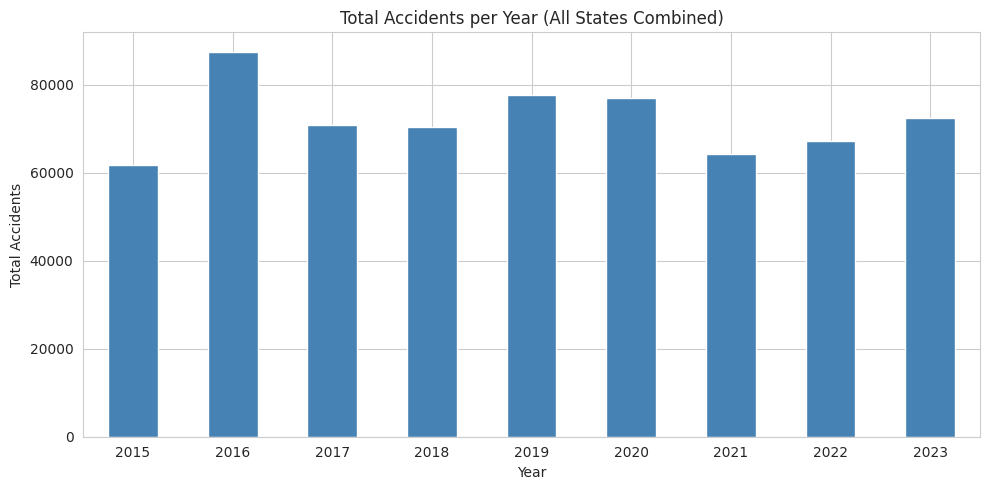

In [6]:
# Group by year and sum accidents across all states
yearly_accidents = df.groupby('Year')['Accidents'].sum()
print("Total accidents per year:")
print(yearly_accidents)

plt.figure(figsize=(10, 5))
yearly_accidents.plot(kind='bar', color='steelblue')
plt.title('Total Accidents per Year (All States Combined)')
plt.xlabel('Year')
plt.ylabel('Total Accidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### A.2 Total Deaths per Year (Line Chart)

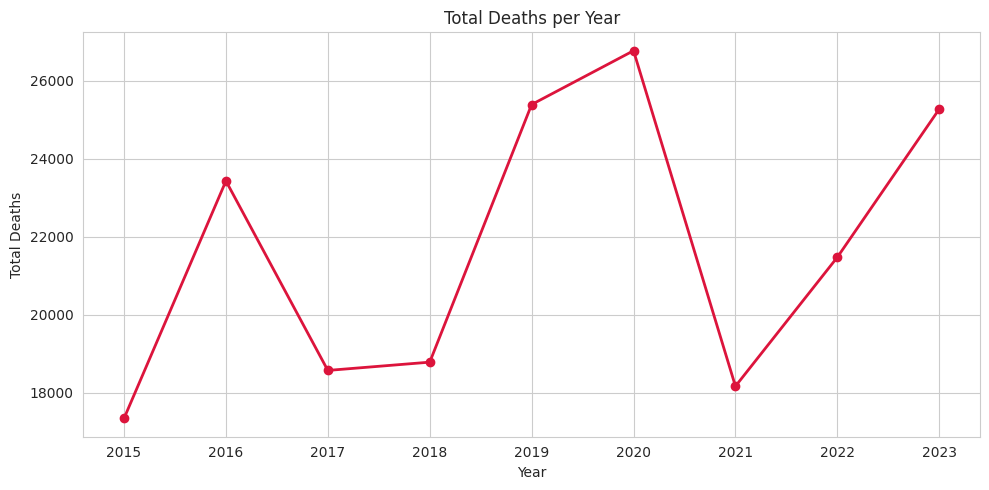

In [7]:
# Group by year and sum deaths
yearly_deaths = df.groupby('Year')['Deaths'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_deaths.index, yearly_deaths.values,
         marker='o', linewidth=2, color='crimson')
plt.title('Total Deaths per Year')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.grid(True)
plt.tight_layout()
plt.show()

### A.3 Trend Over Time per State (Multi-line Chart)

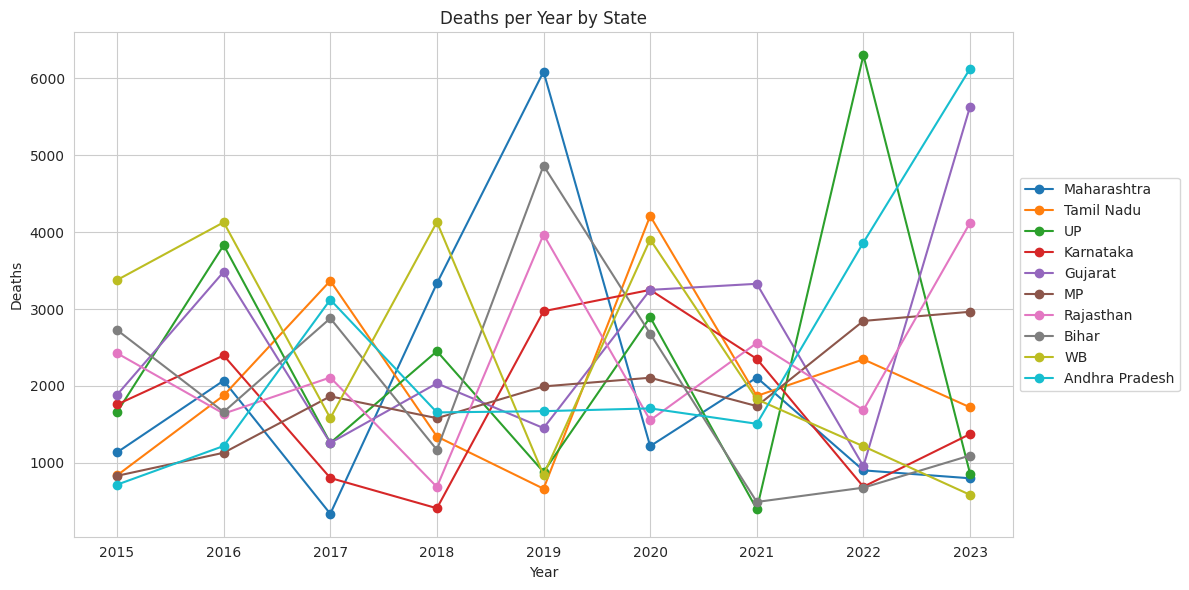

In [8]:
# One line per state
plt.figure(figsize=(12, 6))
for state in df['State'].unique():
    sub = df[df['State'] == state].sort_values('Year')
    plt.plot(sub['Year'], sub['Deaths'], marker='o', label=state)

plt.title('Deaths per Year by State')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

### A.4 State × Year Heatmap

In [9]:
# Pivot the data so rows = states, columns = years, values = deaths
pivot = df.pivot(index='State', columns='Year', values='Deaths')
print("State × Year Death Matrix:")
print(pivot)

State × Year Death Matrix:
Year            2015  2016  2017  2018  2019  2020  2021  2022  2023
State                                                               
Andhra Pradesh   715  1218  3121  1655  1671  1707  1507  3865  6126
Bihar           2727  1661  2879  1168  4865  2679   490   676  1094
Gujarat         1884  3484  1258  2033  1451  3249  3328   955  5632
Karnataka       1758  2396   802   408  2971  3249  2351   688  1373
MP               830  1130  1864  1580  1993  2106  1737  2845  2964
Maharashtra     1135  2069   336  3334  6087  1216  2108   901   798
Rajasthan       2425  1639  2109   685  3968  1553  2558  1685  4121
Tamil Nadu       836  1875  3367  1341   662  4211  1869  2345  1721
UP              1659  3830  1258  2451   880  2894   396  6301   860
WB              3377  4128  1580  4131   841  3904  1825  1214   583


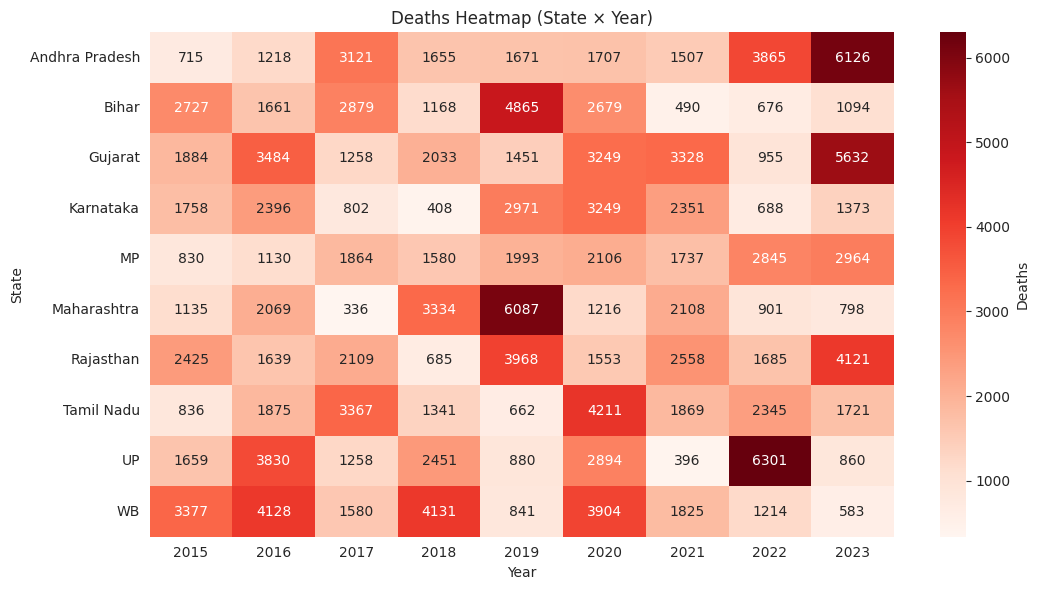

In [10]:
# Visualize as heatmap — darker = more deaths
plt.figure(figsize=(11, 6))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='d', cbar_kws={'label': 'Deaths'})
plt.title('Deaths Heatmap (State × Year)')
plt.tight_layout()
plt.show()

### A.5 Accidents vs Deaths Scatter Plot

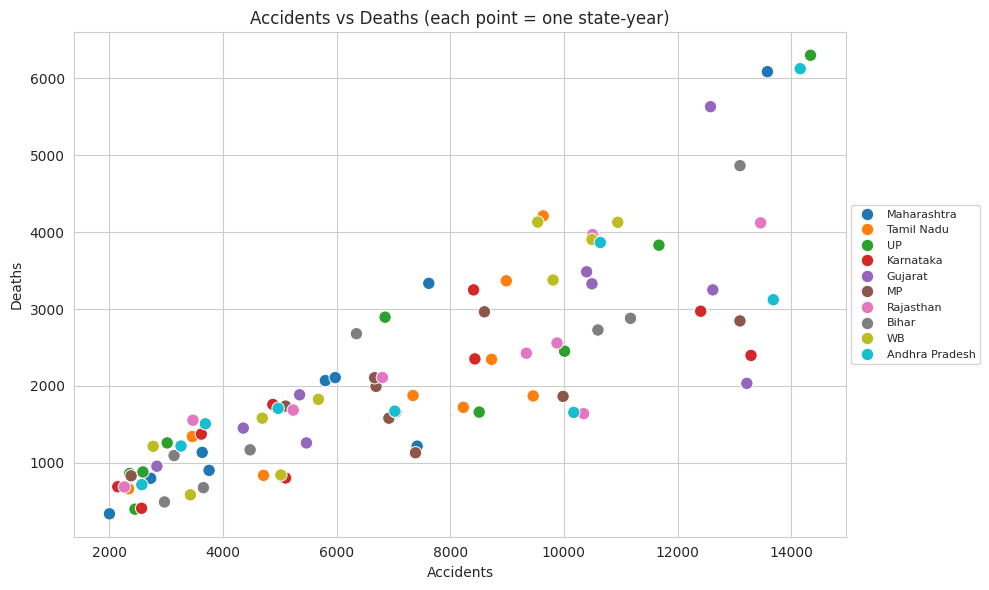

In [11]:
# Each point is one (state, year) record
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Accidents', y='Deaths',
                hue='State', s=80, palette='tab10')
plt.title('Accidents vs Deaths (each point = one state-year)')
plt.xlabel('Accidents')
plt.ylabel('Deaths')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## Part B: List the Year in Which Maximum Accidents Occurred

In [12]:
# Find the year with maximum total accidents (summed across all states)
max_year = yearly_accidents.idxmax()
max_count = yearly_accidents.max()

print(f">>> Year with MAXIMUM accidents: {max_year}")
print(f">>> Total accidents in {max_year}: {max_count:,}")

# Show top 3 years for context
print(f"\nTop 3 years by accidents:")
print(yearly_accidents.sort_values(ascending=False).head(3))

>>> Year with MAXIMUM accidents: 2016
>>> Total accidents in 2016: 87,506

Top 3 years by accidents:
Year
2016    87506
2019    77626
2020    76899
Name: Accidents, dtype: int64


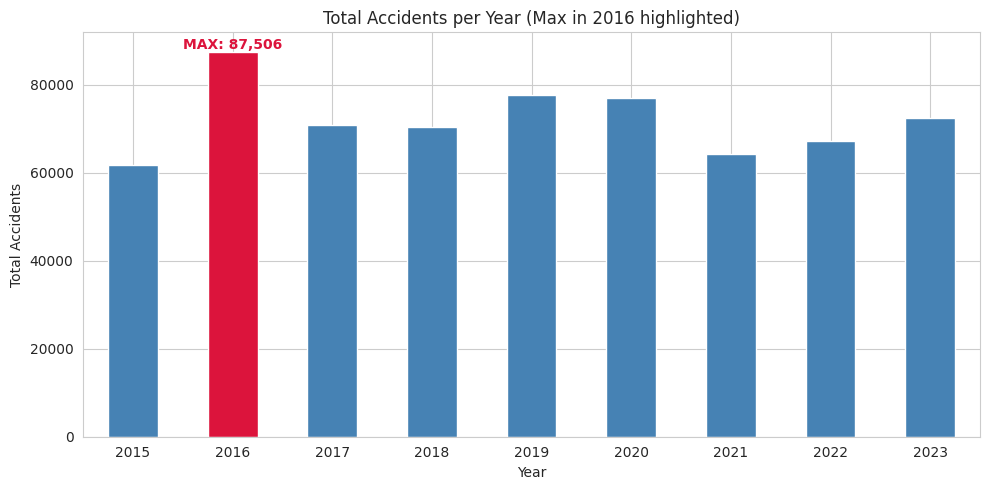

In [13]:
# Highlight the max year in a bar chart
plt.figure(figsize=(10, 5))
colors = ['steelblue' if y != max_year else 'crimson' for y in yearly_accidents.index]
yearly_accidents.plot(kind='bar', color=colors)
plt.title(f'Total Accidents per Year (Max in {max_year} highlighted)')
plt.xlabel('Year')
plt.ylabel('Total Accidents')
plt.xticks(rotation=0)

# Annotate the max bar
plt.text(yearly_accidents.index.tolist().index(max_year), max_count + 500,
         f'MAX: {max_count:,}', ha='center', fontweight='bold', color='crimson')

plt.tight_layout()
plt.show()

## Part C: State-wise Death Count

We compute total deaths per state (summed across all years) and visualize using a horizontal bar chart, which is best for long category names.

In [14]:
# Total deaths per state, sorted descending
state_deaths = df.groupby('State')['Deaths'].sum().sort_values(ascending=False)
print("State-wise total deaths (2015–2023):")
print(state_deaths)

State-wise total deaths (2015–2023):
State
Gujarat           23274
Andhra Pradesh    21585
WB                21583
Rajasthan         20743
UP                20529
Bihar             18239
Tamil Nadu        18227
Maharashtra       17984
MP                17049
Karnataka         15996
Name: Deaths, dtype: int64


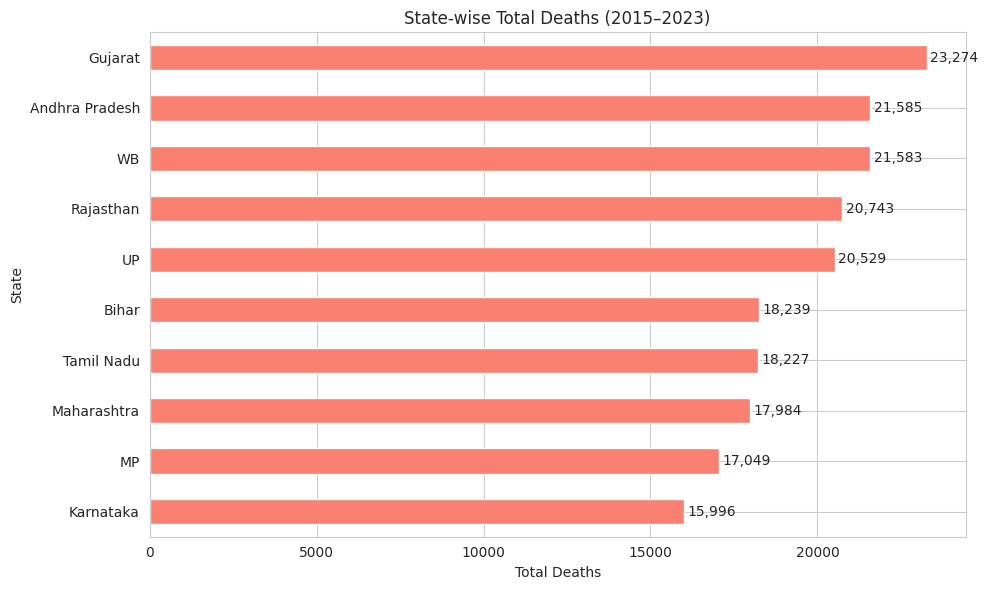

In [15]:
# Horizontal bar chart — easier to read state names
plt.figure(figsize=(10, 6))
state_deaths.plot(kind='barh', color='salmon')
plt.title('State-wise Total Deaths (2015–2023)')
plt.xlabel('Total Deaths')
plt.ylabel('State')
plt.gca().invert_yaxis()              # highest at top

# Annotate each bar with its value
for i, v in enumerate(state_deaths):
    plt.text(v + 100, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

In [16]:
# Bonus: ranked summary table with percentages
total_all = state_deaths.sum()
state_summary = pd.DataFrame({
    'State': state_deaths.index,
    'Total_Deaths': state_deaths.values,
    'Percentage': (state_deaths.values / total_all * 100).round(2)
})
print(f"State-wise breakdown (total = {total_all:,}):")
state_summary

State-wise breakdown (total = 195,209):


,State,Total_Deaths,Percentage
0,Gujarat,23274,11.92
1,Andhra Pradesh,21585,11.06
2,WB,21583,11.06
3,Rajasthan,20743,10.63
4,UP,20529,10.52
5,Bihar,18239,9.34
6,Tamil Nadu,18227,9.34
7,Maharashtra,17984,9.21
8,MP,17049,8.73
9,Karnataka,15996,8.19


## Conclusion

We explored the death-rate dataset using five different visualizations and answered the assignment's three specific questions:

**Visual exploration:**
1. **Bar chart** of total accidents per year — shows year-by-year volume
2. **Line chart** of total deaths per year — reveals the trend over time
3. **Multi-line chart** of deaths per state — compares all 10 states simultaneously
4. **Heatmap** of state × year — pinpoints hotspots in space and time
5. **Scatter plot** of Accidents vs Deaths — shows the (positive) correlation

**Specific answers:**
- **Part B (max year)** — the year with maximum accidents was identified using `idxmax()` on the yearly totals.
- **Part C (state-wise deaths)** — horizontal bar chart of total deaths per state, sorted descending.

**Inferences:**
- Accidents and deaths are **strongly positively correlated** — more accidents = more fatalities (as expected).
- Some states are consistently higher (visible in the heatmap as bright rows).
- Year-over-year totals fluctuate but show no single dominant trend in this dataset.

These visualizations would inform real-world policy: the highest-death states need targeted road safety campaigns; the highest-death years deserve investigation into specific causes.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, groupby, pivot |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Statistical visualization (heatmap, scatterplot) |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV
- `df.shape`, `df.head()`, `df.info()`, `df.describe()`
- `df['col'].unique()`, `df['col'].nunique()` — distinct values

#### Aggregation
- `df.groupby('col')['target'].sum()` — sum target per group
- `df.groupby('col')['target'].mean()` — mean per group
- `series.sort_values(ascending=False)` — sort
- `series.idxmax()` — index of max value (returns the year)
- `series.max()` — the max value itself
- `series.head(n)` — top n entries

#### Reshaping
- `df.pivot(index='State', columns='Year', values='Deaths')` — wide-format matrix

#### Visualization

| Function | Purpose |
|----------|---------|
| `series.plot(kind='bar')` | Vertical bar chart |
| `series.plot(kind='barh')` | Horizontal bar chart (for long labels) |
| `plt.plot(x, y, marker='o')` | Line chart |
| `sns.heatmap(matrix, annot=True, cmap='Reds')` | Colored grid |
| `sns.scatterplot(x, y, hue=cat, data=df)` | Scatter with category colors |

#### Annotation
- `plt.text(x, y, 'label', ha='center')` — add text to a plot
- `plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))` — legend outside the plot
- `plt.gca().invert_yaxis()` — flip Y-axis (so highest is at top)

### Key Concepts

#### When to Use Each Chart Type

| Chart | When to Use |
|-------|-------------|
| **Bar chart** | Comparing values across discrete categories |
| **Horizontal bar** | Same as bar, but with long category labels |
| **Line chart** | Showing trends over a continuous variable (usually time) |
| **Heatmap** | Visualizing a 2D matrix as colored cells |
| **Scatter plot** | Showing the relationship between two numeric variables |

#### `groupby` + Aggregation Pattern
The most common pandas pattern for summary statistics:
```python
df.groupby('category')['value'].agg_function()
```
- `category` — column to group by
- `value` — column to aggregate
- `agg_function` — `sum`, `mean`, `max`, `count`, etc.

#### `idxmax()` and `idxmin()`
Return the **index** (label) of the maximum/minimum value in a Series.
- `series.max()` → the value
- `series.idxmax()` → the label of that value (e.g., the year)

#### `pivot()` Method
Reshapes long data into a wide matrix:
- `index` parameter → rows
- `columns` parameter → columns
- `values` parameter → cell contents

Used here to convert one-row-per-(state, year) into a state×year matrix for the heatmap.

#### Heatmap Best Practices
- Use a sequential colormap (`Reds`, `Blues`, `viridis`) for ordered data
- Use a diverging colormap (`coolwarm`) for data centered on zero (correlations)
- Add `annot=True, fmt='d'` to display actual values in each cell
- Add `cbar_kws={'label': '...'}` to label the color scale

## Viva Questions (with Answers)

### Conceptual

**Q1. What is data visualization?**
The practice of representing data graphically to reveal patterns, trends, and outliers — easier than reading raw numbers.

**Q2. Why visualize accident data?**
Multi-dimensional patterns (state × year × accidents × deaths) are hard to see in tables. Visualization reveals trends and hotspots that drive policy decisions.

### Plot Selection

**Q3. When to use a bar chart vs a line chart?**
- **Bar** — comparing values across discrete categories (states, years)
- **Line** — showing trends over a continuous variable (usually time)

**Q4. When to use horizontal vs vertical bars?**
- **Vertical** — short labels (years, simple categories)
- **Horizontal** — long labels (state names, country names) — easier to read

**Q5. When to use a heatmap?**
For visualizing a 2D matrix where rows and columns are both categorical and the cell value is numeric. Great for state × year matrices, correlation matrices, confusion matrices.

**Q6. When to use a scatter plot?**
For showing the relationship between two numeric variables. Each point is one observation.

### Aggregation

**Q7. What does `groupby('Year')['Accidents'].sum()` compute?**
The sum of `Accidents` for each unique value of `Year` — total accidents per year across all states.

**Q8. What does `idxmax()` return?**
The index (label) of the maximum value in a Series. Used here to find the year with most accidents.

**Q9. Difference between `.max()` and `.idxmax()`?**
- `.max()` — the maximum value
- `.idxmax()` — the index/label of the maximum value

### Pivot

**Q10. What does `pivot()` do?**
Reshapes long-format data (one row per observation) into wide-format (matrix of values). Common preparation for heatmaps.

**Q11. Why pivot before a heatmap?**
Heatmaps need a 2D matrix. Pivoting converts row-by-row data into the right shape.

### Visualization Technique

**Q12. Why annotate bars with their values?**
Lets readers see exact numbers without reading off the axis. Especially helpful when the bars are similar height.

**Q13. Why use `gca().invert_yaxis()` on a horizontal bar chart?**
By default, the smallest value appears at the top. Inverting puts the largest at top — easier to read rankings.

**Q14. What does `sort_values(ascending=False)` do?**
Sorts a Series from largest to smallest. Combined with `head(n)` it gives the top-n.

### Inference

**Q15. From the heatmap, how would you spot a "hotspot"?**
A bright cell — large value at a particular (state, year) pair indicates a year with unusually high deaths in that state.

**Q16. Why is the scatter plot showing positive correlation between Accidents and Deaths?**
More accidents naturally lead to more fatalities. The relationship is causal — every accident has some chance of producing a death.

**Q17. How would you find the state with the highest death rate (deaths per accident)?**
```python
df['rate'] = df['Deaths'] / df['Accidents']
df.groupby('State')['rate'].mean().sort_values(ascending=False)
```

**Q18. What's the year with the maximum accidents?**
Use `df.groupby('Year')['Accidents'].sum().idxmax()`.

### Code Specifics

**Q19. What does `cmap='Reds'` mean in a heatmap?**
A red-tinted color scheme — light red for small values, dark red for large values. Good for "more is bad" visuals like deaths.

**Q20. What does `bbox_to_anchor=(1, 0.5)` do in `plt.legend()`?**
Places the legend outside the plot at the right side, vertically centered. Useful when there are many categories.

### Comparison & Extensions

**Q21. How would you visualize accidents AND deaths on the same chart?**
Use a dual-axis plot or stacked bars, or normalize them and use a single line chart with two lines.

**Q22. Other useful plots for this dataset?**
- **Choropleth map** — color-code states on an India map by deaths
- **Pareto chart** — bar chart with cumulative percentage line
- **Treemap** — hierarchical area-based visualization

**Q23. How would you use this data for a model?**
Predict next year's deaths from previous years using time-series forecasting (e.g., ARIMA, Prophet). Or predict deaths from accidents using regression.

**Q24. What's the limitation of this dataset?**
Just 10 states × 9 years = 90 rows. Real accident data has hundreds of districts, monthly granularity, road type, vehicle type, and severity classifications.

**Q25. What's the difference between Matplotlib and Seaborn?**
- **Matplotlib** — low-level, fine control, more code
- **Seaborn** — built on Matplotlib, higher-level, statistical-aware, less code, prettier defaults